In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the path to your dataset
dataset_path = '/content/drive/MyDrive/lung_cancer_dataset/LUNG'  # Update this path to your dataset folder on Drive


# Data Enhancement

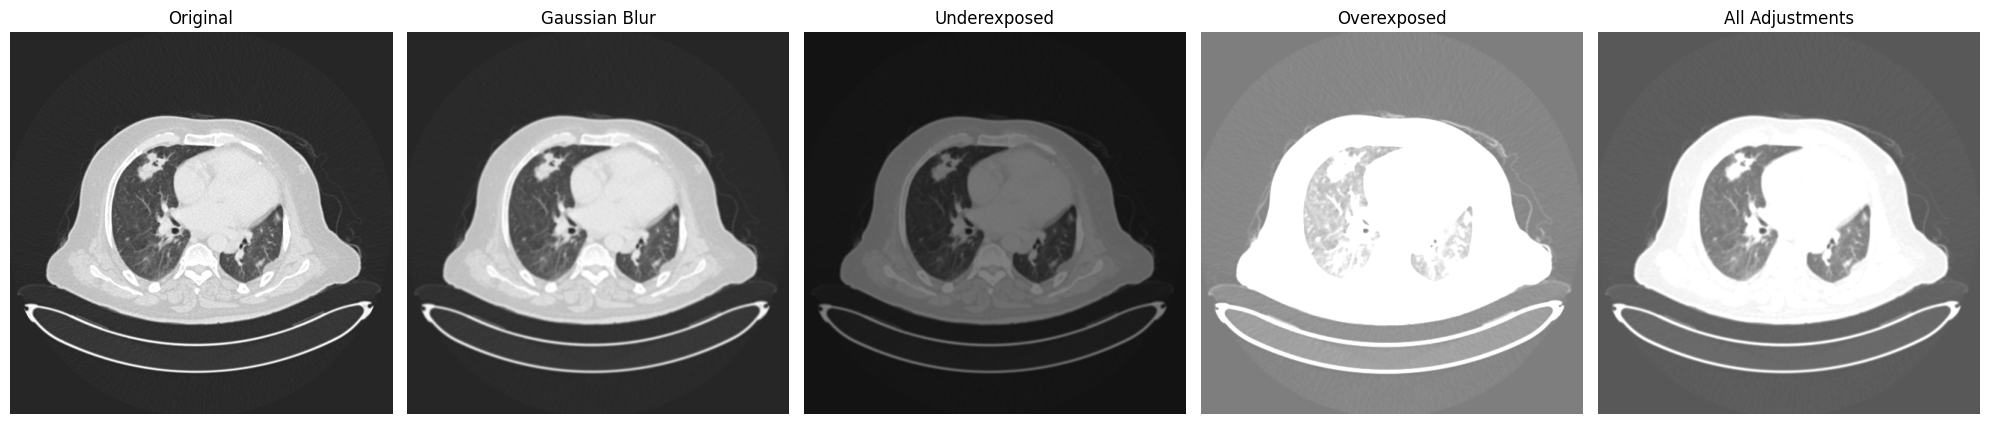

Displayed: Malignant case (104).jpg


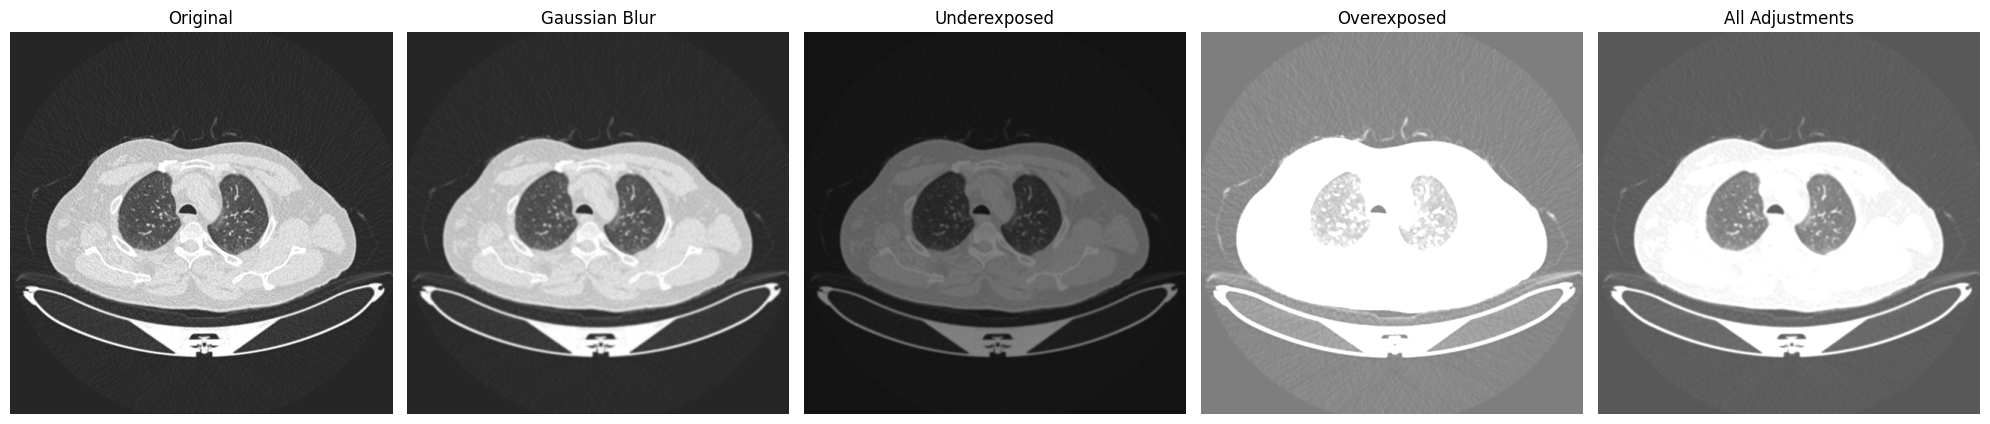

Displayed: Normal case (139).jpg


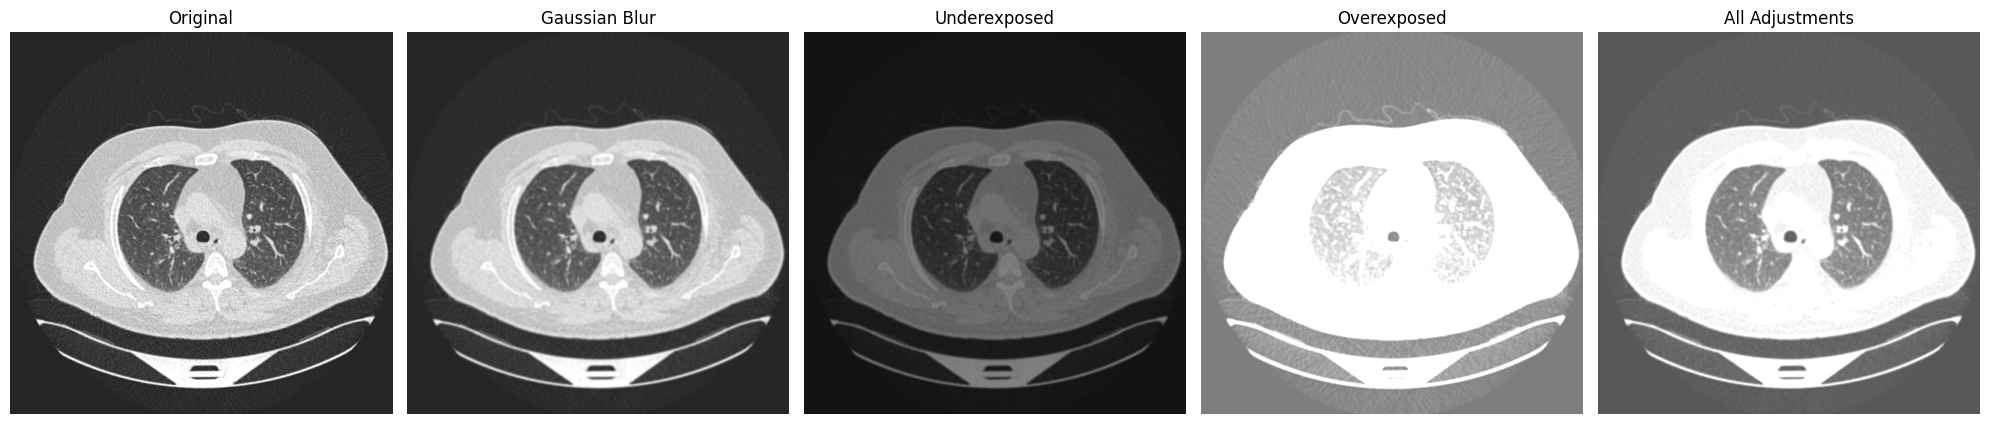

Displayed: Bengin case (100).jpg
Image display completed!


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define input directories
input_base_path = '/content/drive/MyDrive/lung_cancer_dataset/LUNG'

# Degradation functions
def add_gaussian_blur(image, kernel_size=(5, 5), sigma=1):
    return cv2.GaussianBlur(image, kernel_size, sigma)

def vary_contrast(image, alpha=1.5):
    """Adjust the contrast of an image."""
    adjusted_image = cv2.convertScaleAbs(image, alpha=alpha, beta=0)
    return adjusted_image

def simulate_underexposure(image, alpha=0.5, beta=0):
    """Simulate underexposure by reducing brightness and contrast."""
    underexposed_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return underexposed_image

def simulate_overexposure(image, alpha=2.0, beta=50):
    """Simulate overexposure by increasing brightness and contrast."""
    overexposed_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return overexposed_image

# Function to display images
def display_images(original_img, gaussian_blur_img, underexposed_img, overexposed_img, all_adjustments_img):
    # Plot the images in a grid
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    images = [original_img, gaussian_blur_img, underexposed_img, overexposed_img, all_adjustments_img]
    titles = ['Original', 'Gaussian Blur', 'Underexposed', 'Overexposed', 'All Adjustments']

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
        ax.set_title(title)
        ax.axis('off')  # Hide axes

    plt.tight_layout()
    plt.show()

# Process dataset
categories = ['Malignant cases', 'Normal cases', 'Bengin cases']

# Display images for each category
for category in categories:
    input_dir = os.path.join(input_base_path, category)

    for img_name in os.listdir(input_dir):
        img_path = os.path.join(input_dir, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue

        # Apply degradation techniques
        gaussian_blur_img = add_gaussian_blur(image)
        underexposed_img = simulate_underexposure(gaussian_blur_img)
        overexposed_img = simulate_overexposure(gaussian_blur_img)
        all_adjustments_img = simulate_overexposure(underexposed_img)  # Example of all adjustments together

        # Display images
        display_images(image, gaussian_blur_img, underexposed_img, overexposed_img, all_adjustments_img)

        print(f"Displayed: {img_name}")
        break  # Display one image per class for demonstration

print("Image display completed!")


# Split Dataset

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
input_base_path = '/content/drive/MyDrive/Pulmoscan_Dataset_Degraded'
output_base_path = '/content/drive/MyDrive/Pulmoscan_Dataset_Split'
os.makedirs(output_base_path, exist_ok=True)

# Create directories for train, val, test
for split in ['train', 'val', 'test']:
    for category in ['Malignant cases', 'Normal cases', 'Bengin cases']:
        os.makedirs(os.path.join(output_base_path, split, category), exist_ok=True)

# Split each category separately
for category in ['Malignant cases', 'Normal cases', 'Bengin cases']:
    # Get all image paths
    image_dir = os.path.join(input_base_path, category)
    images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # First split: 80% (train+val) and 20% (test)
    train_val, test = train_test_split(images, test_size=0.2, random_state=42)

    # Second split: 75% of 80% = 60% train, 25% of 80% = 20% val
    train, val = train_test_split(train_val, test_size=0.25, random_state=42)

    # Copy files to respective directories
    for img in train:
        src = os.path.join(image_dir, img)
        dst = os.path.join(output_base_path, 'train', category, img)
        shutil.copy(src, dst)

    for img in val:
        src = os.path.join(image_dir, img)
        dst = os.path.join(output_base_path, 'val', category, img)
        shutil.copy(src, dst)

    for img in test:
        src = os.path.join(image_dir, img)
        dst = os.path.join(output_base_path, 'test', category, img)
        shutil.copy(src, dst)

print("Dataset splitting completed!")

Dataset splitting completed!


# Modeling

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4, ResNet50, DenseNet121
from tensorflow.keras import layers, models, optimizers, callbacks
import matplotlib.pyplot as plt
import numpy as np

# Define paths
train_dir = '/content/drive/MyDrive/Pulmoscan_Dataset_Split/train'
val_dir = '/content/drive/MyDrive/Pulmoscan_Dataset_Split/val'
test_dir = '/content/drive/MyDrive/Pulmoscan_Dataset_Split/test'

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
CLASS_NAMES = ['Normal', 'Bengin', 'Malignant']

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test generators (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1396 images belonging to 3 classes.
Found 466 images belonging to 3 classes.
Found 466 images belonging to 3 classes.


# EfficientNetB4

In [ ]:
def create_efficientnet_model():
    base_model = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze base model layers
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )

    return model

# ResNet50

In [ ]:
def create_resnet_model():
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze base model layers
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )

    return model

# Custom CNN

In [ ]:
def create_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )

    return model

# Training Pipeline

In [ ]:
def train_model(model, model_name):
    # Callbacks
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.h5',
            monitor='val_loss',
            save_best_only=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.1,
            patience=3
        )
    ]

    # Train the model
    history = model.fit(
        train_generator,
        epochs=50,
        validation_data=val_generator,
        callbacks=callbacks_list
    )

    # Save training history
    np.save(f'{model_name}_history.npy', history.history)

    return history

# Model Evaluation

In [ ]:
def evaluate_model(model, model_name):
    # Evaluate on test set
    test_results = model.evaluate(test_generator)

    print(f"\n{model_name} Test Results:")
    print(f"Loss: {test_results[0]:.4f}")
    print(f"Accuracy: {test_results[1]:.4f}")
    print(f"Precision: {test_results[2]:.4f}")
    print(f"Recall: {test_results[3]:.4f}")
    print(f"AUC: {test_results[4]:.4f}")

    # Generate predictions
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes

    # Classification report
    from sklearn.metrics import classification_report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{model_name}_confusion_matrix.png')
    plt.show()

    return test_results

# Full Execution Pipeline


Training EfficientNetB4...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4536 - auc: 0.6414 - loss: 1.0725 - precision: 0.4992 - recall: 0.3157

44/44 ━━━━━━━━━━━━━━━━━━━━ 533s 11s/step - accuracy: 0.4547 - auc: 0.6421 - loss: 1.0716 - precision: 0.5002 - recall: 0.3169 - val_accuracy: 0.5365 - val_auc: 0.7009 - val_loss: 0.9871 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 430s 10s/step - accuracy: 0.5028 - auc: 0.6662 - loss: 1.0320 - precision: 0.4922 - recall: 0.2587 - val_accuracy: 0.5365 - val_auc: 0.6967 - val_loss: 1.0025 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5403 - auc: 0.6952 - loss: 0.9984 - precision: 0.5259 - recall: 0.2163

44/44 ━━━━━━━━━━━━━━━━━━━━ 427s 10s/step - accuracy: 0.5402 - auc: 0.6950 - loss: 0.9985 - precision: 0.5258 - recall: 0.2177 - val_accuracy: 0.5365 - val_auc: 0.6912 - val_loss: 0.9864 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 462s 11s/step - accuracy: 0.5283 - auc: 0.6901 - loss: 1.0008 - precision: 0.5450 - recall: 0.2517 - val_accuracy: 0.5365 - val_auc: 0.6917 - val_loss: 0.9897 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 417s 10s/step - accuracy: 0.5266 - auc: 0.6721 - loss: 1.0164 - precision: 0.4963 - recall: 0.1946 - val_accuracy: 0.5365 - val_auc: 0.6906 - val_loss: 0.9867 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5260 - auc: 0.6793 - loss: 1.0091 - precision: 0.5210 - recall: 0.2552

44/44 ━━━━━━━━━━━━━━━━━━━━ 463s 11s/step - accuracy: 0.5262 - auc: 0.6795 - loss: 1.0088 - precision: 0.5214 - recall: 0.2563 - val_accuracy: 0.5365 - val_auc: 0.6914 - val_loss: 0.9855 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 420s 10s/step - accuracy: 0.5421 - auc: 0.6882 - loss: 0.9975 - precision: 0.5216 - recall: 0.3242 - val_accuracy: 0.5365 - val_auc: 0.6936 - val_loss: 0.9865 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 416s 10s/step - accuracy: 0.5240 - auc: 0.6834 - loss: 1.0086 - precision: 0.5157 - recall: 0.3019 - val_accuracy: 0.5365 - val_auc: 0.6903 - val_loss: 0.9869 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 460s 10s/step - accuracy: 0.5248 - auc: 0.6826 - loss: 1.0116 - precision: 0.5426 - recall: 0.2405 - val_accuracy: 0.5365 - val_auc: 0.6937 - val_loss: 0.9861 - val_precision:

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


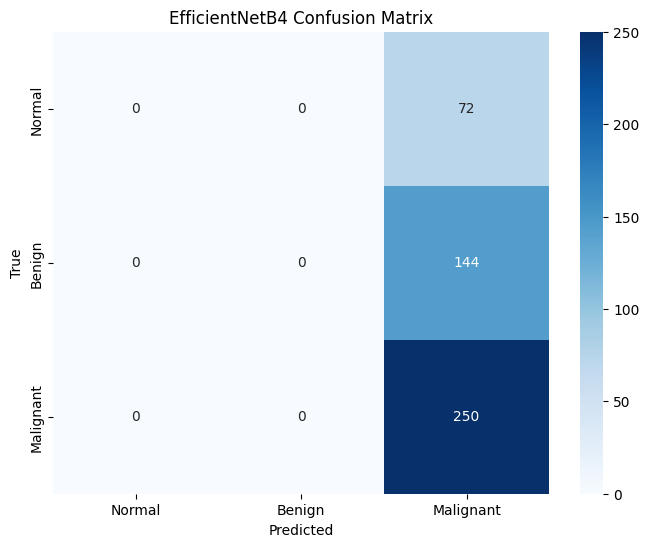

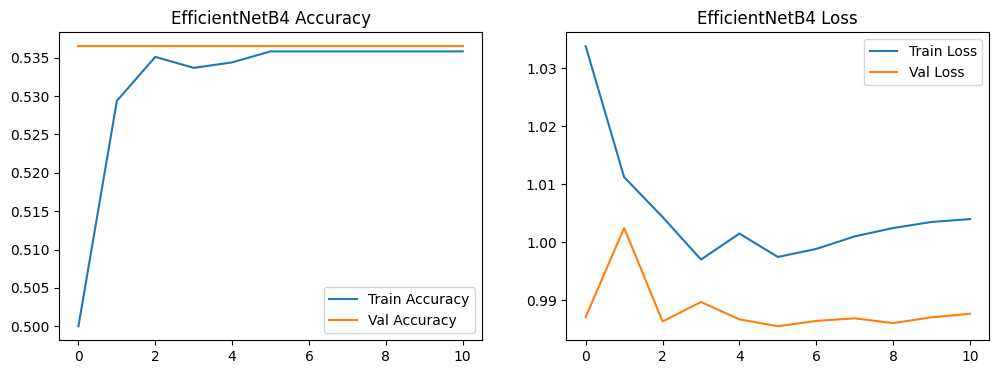


Training ResNet50...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4456 - auc: 0.6327 - loss: 1.1794 - precision: 0.4638 - recall: 0.3574

44/44 ━━━━━━━━━━━━━━━━━━━━ 390s 9s/step - accuracy: 0.4462 - auc: 0.6330 - loss: 1.1778 - precision: 0.4645 - recall: 0.3574 - val_accuracy: 0.5365 - val_auc: 0.7434 - val_loss: 0.9873 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5165 - auc: 0.6814 - loss: 1.0113 - precision: 0.5564 - recall: 0.3514

44/44 ━━━━━━━━━━━━━━━━━━━━ 436s 10s/step - accuracy: 0.5163 - auc: 0.6814 - loss: 1.0113 - precision: 0.5563 - recall: 0.3506 - val_accuracy: 0.5365 - val_auc: 0.7514 - val_loss: 0.9808 - val_precision: 0.8824 - val_recall: 0.0322 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5506 - auc: 0.7103 - loss: 0.9835 - precision: 0.5692 - recall: 0.3563

44/44 ━━━━━━━━━━━━━━━━━━━━ 374s 9s/step - accuracy: 0.5502 - auc: 0.7100 - loss: 0.9838 - precision: 0.5686 - recall: 0.3552 - val_accuracy: 0.5365 - val_auc: 0.7437 - val_loss: 0.9786 - val_precision: 0.6725 - val_recall: 0.4099 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 424s 10s/step - accuracy: 0.5393 - auc: 0.7059 - loss: 0.9839 - precision: 0.5651 - recall: 0.3418 - val_accuracy: 0.5365 - val_auc: 0.7500 - val_loss: 0.9850 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 425s 10s/step - accuracy: 0.5160 - auc: 0.6757 - loss: 1.0142 - precision: 0.4688 - recall: 0.2132 - val_accuracy: 0.5365 - val_auc: 0.7511 - val_loss: 0.9802 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5296 - auc: 0.6975 - loss: 0.9978 - precision: 0.5516 - recall: 0.3235

44/44 ━━━━━━━━━━━━━━━━━━━━ 441s 10s/step - accuracy: 0.5298 - auc: 0.6975 - loss: 0.9978 - precision: 0.5516 - recall: 0.3233 - val_accuracy: 0.5365 - val_auc: 0.7524 - val_loss: 0.9769 - val_precision: 0.5423 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 428s 10s/step - accuracy: 0.5230 - auc: 0.6940 - loss: 0.9953 - precision: 0.5451 - recall: 0.2744 - val_accuracy: 0.5365 - val_auc: 0.7528 - val_loss: 0.9775 - val_precision: 0.5365 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 383s 8s/step - accuracy: 0.5318 - auc: 0.6969 - loss: 0.9952 - precision: 0.5335 - recall: 0.3666 - val_accuracy: 0.5429 - val_auc: 0.7535 - val_loss: 0.9799 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5141 - auc: 0.6877 - loss: 1.0038 - precision: 0.5635 - recall: 0.3227

44/44 ━━━━━━━━━━━━━━━━━━━━ 439s 10s/step - accuracy: 0.5146 - auc: 0.6879 - loss: 1.0036 - precision: 0.5634 - recall: 0.3234 - val_accuracy: 0.5365 - val_auc: 0.7517 - val_loss: 0.9764 - val_precision: 0.5423 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5220 - auc: 0.6738 - loss: 1.0174 - precision: 0.5254 - recall: 0.3081

44/44 ━━━━━━━━━━━━━━━━━━━━ 384s 8s/step - accuracy: 0.5223 - auc: 0.6743 - loss: 1.0170 - precision: 0.5260 - recall: 0.3087 - val_accuracy: 0.5365 - val_auc: 0.7520 - val_loss: 0.9695 - val_precision: 0.5423 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 374s 9s/step - accuracy: 0.5389 - auc: 0.7115 - loss: 0.9733 - precision: 0.5704 - recall: 0.3524 - val_accuracy: 0.5365 - val_auc: 0.7504 - val_loss: 0.9739 - val_precision: 0.5605 - val_recall: 0.5365 - learning_rate: 0.0010
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 373s 8s/step - accuracy: 0.5459 - auc: 0.7060 - loss: 0.9854 - precision: 0.5634 - recall: 0.3724 - val_accuracy: 0.5365 - val_auc: 0.7496 - val_loss: 0.9770 - val_precision: 0.6193 - val_recall: 0.4957 - learning_rate: 0.0010
Epoch 13/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 381s 8s/step - accuracy: 0.5216 - auc: 0.6908 - loss: 1.0036 - precision: 0.5529 - recall: 0.2593 - val_accuracy: 0.5365 - val_auc: 0.7505 - val_loss: 0.9738 - val_precision: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


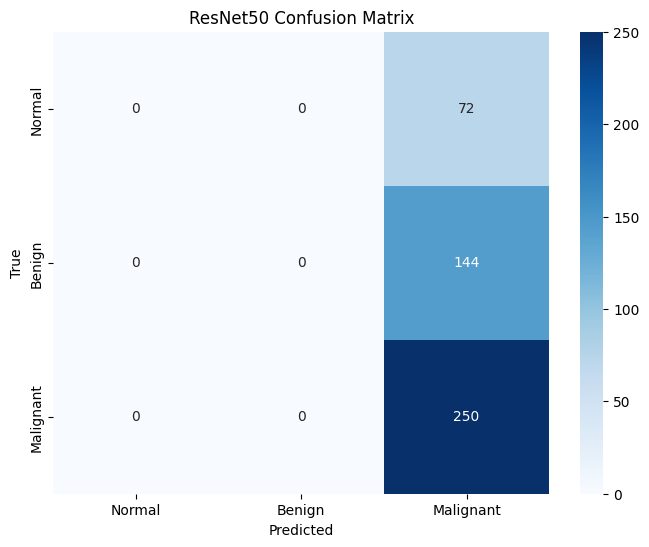

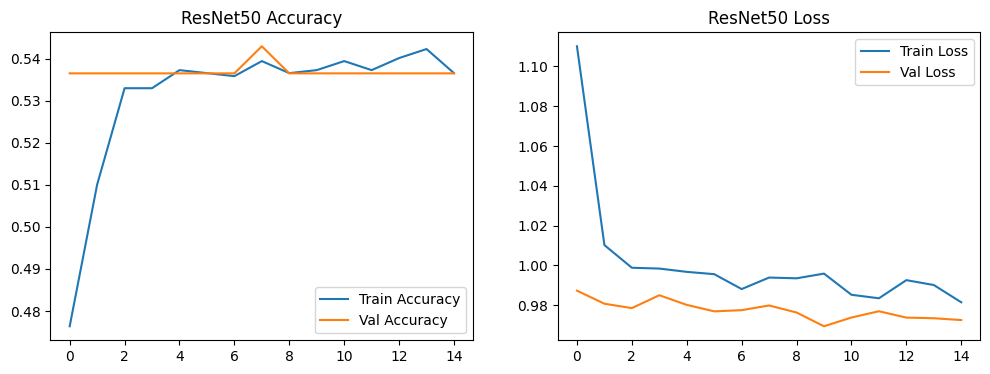


Training CustomCNN...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4981 - auc: 0.6451 - loss: 2.2630 - precision: 0.4690 - recall: 0.2066

44/44 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.4985 - auc: 0.6456 - loss: 2.2439 - precision: 0.4698 - recall: 0.2063 - val_accuracy: 0.5365 - val_auc: 0.7044 - val_loss: 0.9888 - val_precision: 0.5394 - val_recall: 0.1910 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5346 - auc: 0.6896 - loss: 1.0132 - precision: 0.5418 - recall: 0.2458

44/44 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.5346 - auc: 0.6896 - loss: 1.0131 - precision: 0.5420 - recall: 0.2466 - val_accuracy: 0.5451 - val_auc: 0.7237 - val_loss: 0.9693 - val_precision: 0.5582 - val_recall: 0.5451 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5602 - auc: 0.7255 - loss: 0.9575 - precision: 0.5638 - recall: 0.3384

44/44 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.5600 - auc: 0.7251 - loss: 0.9580 - precision: 0.5639 - recall: 0.3372 - val_accuracy: 0.5558 - val_auc: 0.7352 - val_loss: 0.9564 - val_precision: 0.5594 - val_recall: 0.5558 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.5565 - auc: 0.7148 - loss: 0.9672 - precision: 0.5616 - recall: 0.3680 - val_accuracy: 0.5558 - val_auc: 0.7344 - val_loss: 0.9609 - val_precision: 0.6438 - val_recall: 0.2017 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5246 - auc: 0.6978 - loss: 0.9908 - precision: 0.5925 - recall: 0.2365

44/44 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.5255 - auc: 0.6983 - loss: 0.9902 - precision: 0.5930 - recall: 0.2385 - val_accuracy: 0.5558 - val_auc: 0.7455 - val_loss: 0.9432 - val_precision: 0.6364 - val_recall: 0.3906 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5689 - auc: 0.7286 - loss: 0.9520 - precision: 0.5979 - recall: 0.3436

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 260s 5s/step - accuracy: 0.6280 - auc: 0.7771 - loss: 0.8795 - precision: 0.6755 - recall: 0.4982 - val_accuracy: 0.6910 - val_auc: 0.8331 - val_loss: 0.7781 - val_precision: 0.7188 - val_recall: 0.6309 - learning_rate: 0.0010
Epoch 14/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 210s 5s/step - accuracy: 0.6480 - auc: 0.7902 - loss: 0.8518 - precision: 0.6704 - recall: 0.5396 - val_accuracy: 0.6674 - val_auc: 0.8237 - val_loss: 0.7909 - val_precision: 0.7358 - val_recall: 0.5558 - learning_rate: 0.0010
Epoch 15/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.6688 - auc: 0.7976 - loss: 0.8406 - precision: 0.7052 - recall: 0.5407 - val_accuracy: 0.6781 - val_auc: 0.8123 - val_loss: 0.8384 - val_precision: 0.7493 - val_recall: 0.5386 - learning_rate: 0.0010
Epoch 16/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6438 - auc: 0.7828 - loss: 0.8683 - precision: 0.6985 - recall: 0.5145

44/44 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.6438 - auc: 0.7828 - loss: 0.8683 - precision: 0.6984 - recall: 0.5146 - val_accuracy: 0.6910 - val_auc: 0.8379 - val_loss: 0.7658 - val_precision: 0.7073 - val_recall: 0.6481 - learning_rate: 0.0010
Epoch 17/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.6595 - auc: 0.8067 - loss: 0.8274 - precision: 0.7027 - recall: 0.5686 - val_accuracy: 0.6717 - val_auc: 0.8265 - val_loss: 0.7908 - val_precision: 0.6895 - val_recall: 0.6481 - learning_rate: 0.0010
Epoch 18/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6658 - auc: 0.7905 - loss: 0.8474 - precision: 0.6887 - recall: 0.5583

44/44 ━━━━━━━━━━━━━━━━━━━━ 206s 5s/step - accuracy: 0.6657 - auc: 0.7905 - loss: 0.8473 - precision: 0.6889 - recall: 0.5584 - val_accuracy: 0.6953 - val_auc: 0.8427 - val_loss: 0.7583 - val_precision: 0.7343 - val_recall: 0.6524 - learning_rate: 0.0010
Epoch 19/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6492 - auc: 0.7895 - loss: 0.8542 - precision: 0.6940 - recall: 0.5333

44/44 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.6494 - auc: 0.7895 - loss: 0.8541 - precision: 0.6939 - recall: 0.5334 - val_accuracy: 0.6867 - val_auc: 0.8380 - val_loss: 0.7568 - val_precision: 0.7180 - val_recall: 0.6502 - learning_rate: 0.0010
Epoch 20/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.6423 - auc: 0.7905 - loss: 0.8541 - precision: 0.6825 - recall: 0.5445 - val_accuracy: 0.6824 - val_auc: 0.8331 - val_loss: 0.7659 - val_precision: 0.7133 - val_recall: 0.6352 - learning_rate: 0.0010
Epoch 21/50
 2/44 ━━━━━━━━━━━━━━━━━━━━ 2:35 4s/step - accuracy: 0.6484 - auc: 0.8043 - loss: 0.8426 - precision: 0.7271 - recall: 0.5625

KeyboardInterrupt: 

In [ ]:
# Create and train models
models_dict = {
    'EfficientNetB4': create_efficientnet_model(),
    'ResNet50': create_resnet_model(),
    'CustomCNN': create_custom_cnn()
}

results = {}

for name, model in models_dict.items():
    print(f"\nTraining {name}...")
    history = train_model(model, name)
    results[name] = evaluate_model(model, name)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss')
    plt.legend()

    plt.savefig(f'{name}_training_history.png')
    plt.show()

# Class Imbalance Handling


In [ ]:
# Calculate class weights
from sklearn.utils import class_weight
import numpy as np

# Get class labels
train_labels = train_generator.classes

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))

# Modify the fit() call in train_model() to include class weights:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),

        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.1,
            patience=3
        )
    ],
    class_weight=class_weights  # Add this line
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.6661 - auc: 0.8066 - loss: 0.9625 - precision: 0.7447 - recall: 0.3950 - val_accuracy: 0.6803 - val_auc: 0.8288 - val_loss: 0.8134 - val_precision: 0.8398 - val_recall: 0.3712 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 214s 5s/step - accuracy: 0.6710 - auc: 0.7973 - loss: 0.9315 - precision: 0.7633 - recall: 0.2564 - val_accuracy: 0.5408 - val_auc: 0.7591 - val_loss: 0.8857 - val_precision: 0.8333 - val_recall: 0.1931 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.5767 - auc: 0.7448 - loss: 0.9629 - precision: 0.8147 - recall: 0.1799 - val_accuracy: 0.6652 - val_auc: 0.7988 - val_loss: 0.8568 - val_precision: 0.8203 - val_recall: 0.2253 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.6238 - auc: 0.7749 - loss: 0.9215 - precision: 0.7896 - recall: 0.2537 - val_accuracy: 0.6867 - val_auc: 0.8317 - val_loss: 0.7995 - val_pre

# Enhanced Data Pipeline with Better Augmentation


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
import tensorflow as tf
import numpy as np

# Enhanced data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,  # Increased from 20
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,  # Increased from 0.2
    horizontal_flip=True,
    vertical_flip=True,  # Added vertical flip
    brightness_range=[0.7, 1.3],  # Added brightness adjustment
    fill_mode='nearest'
)

# Validation and test generators (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Calculate class weights
def get_class_weights(directory):
    classes = []
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(directory, class_name + " cases")
        classes.append(len(os.listdir(class_dir)))

    total = sum(classes)
    class_weights = {
        i: total/(len(classes)*count) for i, count in enumerate(classes)
    }
    return class_weights

class_weights = get_class_weights(train_dir)
print("Class weights:", class_weights)

# Create data generators with balanced batches
from tensorflow.keras.utils import to_categorical

class BalancedDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, generator):
        self.generator = generator
        self.class_indices = generator.class_indices
        self.classes = generator.classes
        self.num_classes = len(generator.class_indices)
        self.class_counts = np.bincount(self.classes)
        self.max_class_count = np.max(self.class_counts)
        self.index_array = []

        for class_idx in range(self.num_classes):
            class_indices = np.where(self.classes == class_idx)[0]
            repeats = int(np.ceil(self.max_class_count / self.class_counts[class_idx]))
            self.index_array.extend(np.tile(class_indices, repeats))

        np.random.shuffle(self.index_array)

    def __len__(self):
        return int(np.ceil(len(self.index_array) / self.generator.batch_size))

    def __getitem__(self, idx):
        batch_size = self.generator.batch_size
        start = idx * batch_size
        end = min(start + batch_size, len(self.index_array))
        batch_indices = self.index_array[start:end]

        x_batch = []
        y_batch = []

        for i in batch_indices:
            x, y = self.generator[i // self.generator.samples]
            x_batch.append(x[0])
            y_batch.append(y[0])

        return np.array(x_batch), np.array(y_batch)

# Create balanced generators
train_generator = BalancedDataGenerator(
    train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Class weights: {0: 0.6221033868092691, 1: 2.154320987654321, 2: 1.0771604938271604}
Found 1396 images belonging to 3 classes.
Found 466 images belonging to 3 classes.
Found 466 images belonging to 3 classes.


# Improved Model Architectures
Option 1: Enhanced EfficientNet with Attention


In [ ]:
def create_enhanced_efficientnet():
    base_model = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Freeze initial layers
    for layer in base_model.layers[:100]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)

    # Add attention mechanism
    attention = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid')(x)
    x = layers.multiply([x, attention])

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.6)(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )

    return model

Option 2: Custom CNN with Residual Connections


In [ ]:
def create_residual_cnn():
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Initial conv block
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)  # Now 112x112x32 (if input is 224x224)

    # Residual block 1 - FIXED
    residual = layers.Conv2D(64, (1,1), strides=(1,1), padding='same')(x)  # Match channels
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual])  # Now both are 112x112x64
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)  # Now 56x56x64

    # Residual block 2 - FIXED
    residual = layers.Conv2D(128, (1,1), strides=(2,2), padding='same')(x)  # Match downsampling
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)  # Now 28x28x128
    x = layers.add([x, residual])  # Both 28x28x128
    x = layers.Activation('relu')(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model

#  Advanced Training Strategy


In [ ]:
def train_enhanced_model(model, model_name):
    # Enhanced callbacks
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor='val_f1_score',  # Changed to monitor F1 score
            patience=10,
            mode='max',
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.h5',
            monitor='val_f1_score',
            save_best_only=True,
            mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        ),
        callbacks.TensorBoard(
            log_dir=f'logs/{model_name}',
            histogram_freq=1
        )
    ]

    # Train with both class weights and balanced batches
    history = model.fit(
        train_generator,
        epochs=100,
        validation_data=val_generator,
        callbacks=callbacks_list,
        class_weight=class_weights
    )

    return history

# Comprehensive Evaluation


In [ ]:
def enhanced_evaluation(model, model_name):
    # Evaluate on test set
    test_results = model.evaluate(test_generator)

    print(f"\n{model_name} - Comprehensive Evaluation:")
    print(f"- Test Loss: {test_results[0]:.4f}")
    print(f"- Accuracy: {test_results[1]:.4f}")
    print(f"- Precision: {test_results[2]:.4f}")
    print(f"- Recall: {test_results[3]:.4f}")
    print(f"- AUC: {test_results[4]:.4f}")
    if len(test_results) > 5:
        print(f"- F1 Score: {test_results[5]:.4f}")

    # Generate predictions
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes

    # Classification report
    from sklearn.metrics import classification_report
    print("\nDetailed Classification Report:")
    print(classification_report(
        y_true,
        y_pred_classes,
        target_names=CLASS_NAMES,
        digits=4
    ))

    # Confusion matrix with percentages
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    cm = confusion_matrix(y_true, y_pred_classes)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f'{model_name} Normalized Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{model_name}_confusion_matrix_percent.png')
    plt.show()

    # ROC Curve for multi-class
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i], tpr[i],
            color=color,
            label=f'ROC curve ({CLASS_NAMES[i]}) (AUC = {roc_auc[i]:.2f})'
        )

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.savefig(f'{model_name}_roc_curve.png')
    plt.show()

    return test_results

#  Execution and Comparison


Found 1396 images belonging to 3 classes.
Found 466 images belonging to 3 classes.
Found 466 images belonging to 3 classes.
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.3611 - auc: 0.4859 - loss: 0.0183 

22/22 ━━━━━━━━━━━━━━━━━━━━ 744s 33s/step - accuracy: 0.3620 - auc: 0.4872 - loss: 0.0183 - val_accuracy: 0.1545 - val_auc: 0.3106 - val_loss: 1.1732 - learning_rate: 0.0010
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 721s 33s/step - accuracy: 0.2279 - auc: 0.3864 - loss: 0.0176 - val_accuracy: 0.5365 - val_auc: 0.6860 - val_loss: 1.0658 - learning_rate: 0.0010
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 718s 33s/step - accuracy: 0.2521 - auc: 0.4584 - loss: 0.0175 - val_accuracy: 0.1545 - val_auc: 0.4193 - val_loss: 1.1441 - learning_rate: 0.0010
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 711s 33s/step - accuracy: 0.2506 - auc: 0.4302 - loss: 0.0174 - val_accuracy: 0.3090 - val_auc: 0.3879 - val_loss: 1.1169 - learning_rate: 0.0010
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 708s 33s/step - accuracy: 0.4000 - auc: 0.5632 - loss: 0.0174 - val_accuracy: 0.3090 - val_auc: 0.3833 - val_loss: 1.1474 - learning_rate: 0.0010
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 711s 33s/step - accuracy: 0.3499 - auc: 0.4488 - loss

22/22 ━━━━━━━━━━━━━━━━━━━━ 708s 32s/step - accuracy: 0.1819 - auc: 0.3391 - loss: 0.0172 - val_accuracy: 0.1545 - val_auc: 0.3055 - val_loss: 1.1120 - learning_rate: 1.0000e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 183s 22s/step
                 precision    recall  f1-score   support

   Normal cases       0.15      1.00      0.27        72
   Bengin cases       0.00      0.00      0.00       144
Malignant cases       0.00      0.00      0.00       250

       accuracy                           0.15       466
      macro avg       0.05      0.33      0.09       466
   weighted avg       0.02      0.15      0.04       466



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


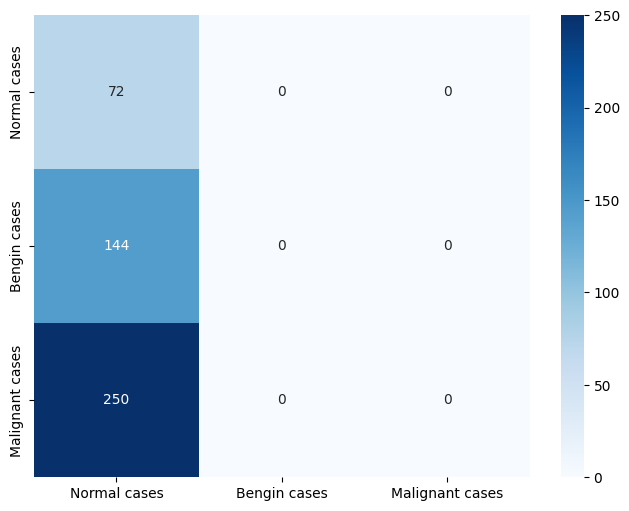

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # Increased batch size
NUM_CLASSES = 3
CLASS_NAMES = ['Normal cases', 'Bengin cases', 'Malignant cases']
EPOCHS = 30  # Reduced with early stopping

# Data generators with optimized settings
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Calculate class weights
class_weights = {i: len(train_gen)/NUM_CLASSES/len(np.where(train_gen.classes == i)[0])
                for i in range(NUM_CLASSES)}

# Build optimized model
base_model = applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Custom learning rate schedule
def lr_schedule(epoch):
    if epoch < 10:
        return 1e-3
    elif epoch < 20:
        return 1e-4
    else:
        return 1e-5

# Callbacks
callbacks = [
    callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max'),
    callbacks.LearningRateScheduler(lr_schedule),
    callbacks.ModelCheckpoint('best_model.h5', monitor='val_auc', save_best_only=True)
]

# Compile with class weights
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Train the model
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

# Evaluate
y_pred = model.predict(test_gen)
y_true = test_gen.classes

print(classification_report(y_true, np.argmax(y_pred, axis=1), target_names=CLASS_NAMES))

# Plot confusion matrix
cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
CLASS_NAMES = ['Normal cases', 'Bengin cases', 'Malignant cases']
EPOCHS = 50

# Data Paths
base_dir = '/content/drive/MyDrive/Pulmoscan_Dataset_Split'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

def create_data_generators():
    # Calculate class weights
    train_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in CLASS_NAMES]
    total = sum(train_counts)
    class_weights = {i: total/(NUM_CLASSES*count) for i, count in enumerate(train_counts)}
    print(f"Class weights: {class_weights}")

    # Data augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    # Create generators
    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    val_gen = val_datagen.flow_from_directory(
        val_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen, test_gen, class_weights

def build_model():
    # Create base model without drop_connect_rate
    base_model = applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    # Build model with attention
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs)

    # Channel attention
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, base_model.output_shape[-1]))(gap)
    conv = layers.Conv2D(base_model.output_shape[-1]//8, 1, activation='relu')(gap)
    conv = layers.Conv2D(base_model.output_shape[-1], 1, activation='sigmoid')(conv)
    x = layers.multiply([x, conv])

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Focal loss for class imbalance
    def focal_loss(gamma=2.0, alpha=0.25):
        def loss(y_true, y_pred):
            epsilon = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, epsilon, 1.-epsilon)
            cross_entropy = -y_true * tf.math.log(y_pred)
            weight = alpha * y_true * tf.pow((1-y_pred), gamma)
            return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
        return loss

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(),
        metrics=['accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')]
    )

    return model, base_model

def train_model(model, base_model, train_gen, val_gen, class_weights):
    # Callbacks
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor='val_auc',
            patience=8,
            mode='max',
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        ),
        callbacks.ModelCheckpoint(
            'best_model.h5',
            monitor='val_auc',
            save_best_only=True,
            mode='max'
        )
    ]

    # Stage 1: Train classifier head
    print("\n=== Stage 1: Training classifier head ===")
    history1 = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=callbacks_list
    )

    # Stage 2: Fine-tune top layers
    print("\n=== Stage 2: Fine-tuning ===")
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    history2 = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=callbacks_list
    )

    return model, history1, history2

def evaluate_model(model, test_gen):
    # Generate predictions
    y_pred = model.predict(test_gen)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_gen.classes

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred_classes,
                              target_names=CLASS_NAMES, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Normalized Confusion Matrix')
    plt.show()

    # ROC Curve
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    fpr, tpr, roc_auc = {}, {}, {}

    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i],
                label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.show()

def main():
    # Create data generators
    train_gen, val_gen, test_gen, class_weights = create_data_generators()

    # Build model
    model, base_model = build_model()
    model.summary()

    # Train model
    model, history1, history2 = train_model(model, base_model, train_gen, val_gen, class_weights)

    # Evaluate model
    evaluate_model(model, test_gen)

    # Save final model
    model.save('lung_cancer_classifier_high_acc.h5')
    print("\n=== Training completed ===")

if __name__ == '__main__':
    main()

Class weights: {0: 0.6221033868092691, 1: 2.154320987654321, 2: 1.0771604938271604}
Found 1396 images belonging to 3 classes.
Found 466 images belonging to 3 classes.
Found 466 images belonging to 3 classes.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_5[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 1, 1, 160) │    204,960 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 1, 1,      │    206,080 │ conv2d_2[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│ (Multiply)          │ 1280)             │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        771 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,790,342 (18.27 MB)

 Trainable params: 740,259 (2.82 MB)

...

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3595 - auc: 0.5287 - loss: 0.2458 - precision: 0.3552 - recall: 0.2179 

44/44 ━━━━━━━━━━━━━━━━━━━━ 717s 16s/step - accuracy: 0.3604 - auc: 0.5297 - loss: 0.2454 - precision: 0.3564 - recall: 0.2187 - val_accuracy: 0.3090 - val_auc: 0.5793 - val_loss: 0.1144 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 694s 16s/step - accuracy: 0.4172 - auc: 0.6150 - loss: 0.2055 - precision: 0.4557 - recall: 0.2924 - val_accuracy: 0.3090 - val_auc: 0.5753 - val_loss: 0.1138 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4352 - auc: 0.6146 - loss: 0.1922 - precision: 0.4599 - recall: 0.2444 

44/44 ━━━━━━━━━━━━━━━━━━━━ 695s 16s/step - accuracy: 0.4354 - auc: 0.6149 - loss: 0.1920 - precision: 0.4599 - recall: 0.2441 - val_accuracy: 0.5365 - val_auc: 0.6355 - val_loss: 0.1096 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4710 - auc: 0.6448 - loss: 0.1689 - precision: 0.4678 - recall: 0.2282 

44/44 ━━━━━━━━━━━━━━━━━━━━ 693s 16s/step - accuracy: 0.4708 - auc: 0.6448 - loss: 0.1689 - precision: 0.4676 - recall: 0.2278 - val_accuracy: 0.5365 - val_auc: 0.6914 - val_loss: 0.1084 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4173 - auc: 0.6369 - loss: 0.1679 - precision: 0.4532 - recall: 0.1533 

44/44 ━━━━━━━━━━━━━━━━━━━━ 693s 16s/step - accuracy: 0.4180 - auc: 0.6371 - loss: 0.1677 - precision: 0.4537 - recall: 0.1533 - val_accuracy: 0.5365 - val_auc: 0.6933 - val_loss: 0.1090 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/50
15/44 ━━━━━━━━━━━━━━━━━━━━ 5:40 12s/step - accuracy: 0.4888 - auc: 0.6537 - loss: 0.1571 - precision: 0.5083 - recall: 0.1869